# 03 (new rule) — Model and prompt comparison with a position limit

Same experiment as notebook 03, with one rule added to the game: **no single position may exceed 25% of equity**, enforced by the engine on every agent — the three prompts, the momentum controls and all the random traders — and stated in every prompt.

Why. In notebook 03, without a limit, the loosest prompt (v1, the leaderboard-style mandate) made +11% by adding to one name until it was 98% of the account; the disciplined prompt, which sized at 10-20%, made nothing. That comparison was between one prompt that could bet the account and two that could not, so it said nothing about the prompts themselves. A per-name limit is what any real account has; with it in place, the only thing that differs between the three runs is the prompt.

The original question stands: **does a better model or a better prompt help more?**

Every configuration below faces the same decision cycles (the first cell prints how many and the exact window), the same rules, the same controls and the same benchmarks. Positions still open when the window ends are closed at the last close, fee charged, so trade statistics include them.

**Candidate mode.** `CANDIDATES = "universe"` (default) makes every one of the 50 names a candidate: the model gets one feature row per name and candles only for what it holds. `"screened"` is the original design — a daily top-5 funnel by dollar volume × recent move, with candles for those five. The first comparison in this project used the funnel, and 1,000 random traders under each mode (section 6) showed the funnel itself moved the median outcome by more than any model or prompt did; the whole-universe mode removes that confound. Results and caches of the two modes are kept apart. Configurations run one after another (leave it overnight); every call is cached, so an interrupted run resumes where it stopped and re-running the notebook is free.

What is compared, per configuration:
- **validity** — usable answers, repairs needed
- **rule-violation rate** — decisions the engine had to refuse (second open in a cycle, add to a loser, …)
- **stop-out rate** — trades closed by the invalidation monitor rather than by choice
- **win rate, return, Sharpe, max drawdown** — against the momentum and random controls and the SPY / equal-weight benchmarks
- **seconds per decision** — the cost of the experiment
- **percentile against 1,000 random traders** — the same rules, the same window, no information: skill or luck?

A few dozen cycles is the minimum for differences to mean anything; treat the result as a first reading, not a verdict.

**Reproducing this.** The decision window is pinned in the first cell, so the result does not move when the price cache is refreshed. Two things sit outside that guarantee: prices come from yfinance and are split- and dividend-adjusted retroactively, so a clone run months from now can see slightly different history for the same dates; and the cache in `data/llm_cache/` is what makes a re-run free — delete it and the models are queried again, and a local model is not bit-identical across versions. Cached, this notebook replays exactly; uncached, treat it as a re-run.

In [1]:
import sys, json, time, logging
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
logging.basicConfig(level=logging.WARNING, format="%(message)s")
pd.set_option("display.width", 180, "display.max_columns", 40, "display.max_colwidth", 100)

from alphabench.universe import TICKERS, ALL_SYMBOLS, UNIVERSE, BENCHMARK
from alphabench.market import load_prices
from alphabench.agents import LLMAgent, OllamaBackend, OpenAICompatibleBackend, Momentum10, RandomAgent, load_env_file
from alphabench.compare import default_configs, mark_runnable, run_configs, PROMPTS
from alphabench.replay import run_replay, decision_dates
from alphabench.metrics import leaderboard, equal_weight_index, calibration, concentration

CACHE     = ROOT / "data" / "prices.parquet"
LLM_CACHE = ROOT / "data" / "llm_cache"
md = load_prices(ALL_SYMBOLS, "2023-09-01", None, CACHE)

CANDIDATES = "universe"              # "universe" = all 50 names are candidates (no funnel); "screened" = daily top-5 screener
MAX_POSITION_WEIGHT = 0.25   # per-name cap as a share of equity, enforced on every agent. None = the leaderboard rules
PAYLOAD = {"candidates": CANDIDATES}
OTHER = "screened" if CANDIDATES == "universe" else "universe"
CAP_TAG = "" if MAX_POSITION_WEIGHT is None else f"_cap{int(round(MAX_POSITION_WEIGHT * 100))}"
RESULTS = ROOT / "data" / "results" / (("compare" if CANDIDATES == "screened" else "compare_universe") + CAP_TAG)

# ---- the fixed window: same cycles for everyone, independent of when prices were last refreshed
WINDOW_START, N_CYCLES = "2026-06-01", 60          # N_CYCLES is a cap; the printed count is what actually ran
dds = decision_dates(md, WINDOW_START)[:N_CYCLES]
START, END = dds[0], dds[-1]
print(f"{len(dds)} cycles: {START.date()} → {END.date()}")

60 cycles: 2026-06-01 → 2026-08-25


## 1. Configurations

The list lives in `alphabench/compare.py` (`default_configs`) so the notebook and `scripts/run_compare.py` run exactly the same thing. `prompt` v1 = TradeRank-style mandate, v2 = v1 + risk rules, v3 = full decision procedure; `think` turns on Qwen3's reasoning mode (slower, may decide better). Models that are not pulled are skipped — `ollama pull <name>`.

**Tip:** run the long part from a terminal instead — `python scripts/run_compare.py --candidates universe --cap 0.25` — and come back to this notebook for the tables; the cache makes section 3 instant afterwards.

**Hosted frontier model.** `FRONTIER_MODEL` adds the same three prompts on a hosted model through the OpenAI-compatible backend (default `"gpt-5.1"`; set it to `None` to stay fully local, in which case nothing is sent anywhere). The key is read from `OPENAI_API_KEY`, from `local_settings.py` in the repo root (copy `local_settings.example.py` and paste the key) or from a `.env` file — all gitignored. The first pass makes about 200 live calls, roughly $5 at gpt-5.1 list prices; every call is cached, so re-running is free. You can also run the long part from a terminal, `python scripts/run_compare.py --cap 0.25 --frontier gpt-5.1 --frontier-only`, and let this notebook read the cache.

In [2]:
FRONTIER_MODEL = "gpt-5.1"    # the same prompts on a hosted model; None = local Ollama configs only, no network calls
REASONING = "low"             # reasoning_effort for gpt-5 / o-series (part of the cache key)
load_env_file(ROOT)           # OPENAI_API_KEY from local_settings.py or .env in the repo root
hosted = OpenAICompatibleBackend(base_url="https://api.openai.com/v1", api_key_env="OPENAI_API_KEY", reasoning_effort=REASONING)
backends = {False: OllamaBackend(think=False), True: OllamaBackend(think=True), "openai": hosted}
RUN_THINKING = False          # True also runs qwen3-8b_v3_thinking (~2-3x slower per call)
ONLY = None                   # e.g. ["qwen3-8b_v3"] to run a single configuration

CONFIGS = mark_runnable(default_configs(think_enabled=RUN_THINKING, candidates=CANDIDATES, max_position_weight=MAX_POSITION_WEIGHT, frontier_model=FRONTIER_MODEL),
                        set(backends[False].list_models()), ONLY, available_remote=set(hosted.list_models()) if FRONTIER_MODEL else None)
for c in CONFIGS:
    print(f"{'▶' if c['runnable'] else '–'} {c['name']:28s} {c['model']:14s} prompt {c['prompt']}  {c['skip_reason'] or ''}")

▶ qwen3-8b_v1_all50_cap25      qwen3:8b       prompt v1  
▶ qwen3-8b_v2_all50_cap25      qwen3:8b       prompt v2  
▶ qwen3-8b_v3_all50_cap25      qwen3:8b       prompt v3  
– qwen3-14b_v3_all50_cap25     qwen3:14b      prompt v3  model not pulled
– gemma3-12b_v3_all50_cap25    gemma3:12b     prompt v3  model not pulled
– qwen3-8b_v3_thinking_all50_cap25 qwen3:8b       prompt v3  disabled
▶ gpt-5-1_v1_all50_cap25       gpt-5.1        prompt v1  
▶ gpt-5-1_v2_all50_cap25       gpt-5.1        prompt v2  
▶ gpt-5-1_v3_all50_cap25       gpt-5.1        prompt v3  


## 2. Controls and benchmarks (seconds)

Two momentum rules as controls: the same 10-day signal, one allowed to short and one not. Longs and shorts compete for the one new position per cycle the engine allows, ranked together by absolute momentum, so the long/short control really does short (an earlier version considered a short only when no long qualified, which on 50 names never happens, and the two controls were then the same agent under two names).

Random traders are not two seeds here but a whole distribution — section 6 runs 1,000 of them.

In [3]:
controls = run_replay(md, [Momentum10(allow_short=True), Momentum10(allow_short=False)],
                      START, END, log_dir=RESULTS / "controls", progress=False, payload_kwargs=PAYLOAD, max_position_weight=MAX_POSITION_WEIGHT)
first, last = controls["control_momentum_10d_ls"]["equity"].index[[0, -1]]   # benchmarks must cover exactly the replay window
benchmarks = {"spy": (md.close[BENCHMARK].loc[first:last] / md.close[BENCHMARK].loc[first] * 10_000),
              "ew_universe": equal_weight_index(md.close[TICKERS], start=first).loc[:last]}
print("controls done")

controls done


## 3. Run the configurations (long — leave it running)

One line per cycle (latency or *cached*, running equity, elapsed, ETA). Safe to interrupt; re-running resumes from the cache. For a quick look set `N_CYCLES = 10` in the first cell.

In [4]:
llm_results, agents, timings = run_configs(md, CONFIGS, START, END, RESULTS, LLM_CACHE, backends, payload_kwargs=PAYLOAD)
results = {**controls, **llm_results}


→ qwen3-8b_v1_all50_cap25  (qwen3:8b, prompt v1)
  cycle   1/60 2026-06-01   cached  equity     9,980  elapsed    0 min  eta    0 min
  cycle   2/60 2026-06-02   cached  equity     9,953  elapsed    0 min  eta    0 min
  cycle   3/60 2026-06-03   cached  equity     9,959  elapsed    0 min  eta    0 min
  cycle   4/60 2026-06-04   cached  equity     9,938  elapsed    0 min  eta    0 min
  cycle   5/60 2026-06-05   cached  equity     9,925  elapsed    0 min  eta    0 min
  cycle   6/60 2026-06-08   cached  equity     9,870  elapsed    0 min  eta    0 min
  cycle   7/60 2026-06-09   cached  equity     9,862  elapsed    0 min  eta    0 min
  cycle   8/60 2026-06-10   cached  equity     9,850  elapsed    0 min  eta    0 min
  cycle   9/60 2026-06-11   cached  equity     9,828  elapsed    0 min  eta    0 min
  cycle  10/60 2026-06-12   cached  equity     9,803  elapsed    0 min  eta    0 min
  cycle  11/60 2026-06-15   cached  equity     9,791  elapsed    0 min  eta    0 min
  cycle  12/60 

## 4. Comparison

In [5]:
def violation_rate(res):
    n_items = sum(len(r["decision"]["decisions"]) for r in res["log"])
    n_rej = 0 if res["rejections"].empty else len(res["rejections"])
    return n_rej / n_items if n_items else np.nan

lb = leaderboard(results, benchmarks)
lb["rule_violation_rate"] = [violation_rate(results[a]) for a in lb["agent"]]
lb["no_action_share"] = [sum(1 for r in results[a]["log"] if not r["decision"]["decisions"]) / len(results[a]["log"]) for a in lb["agent"]]
for col, key in [("validity", None), ("repairs", "repairs"), ("s_per_call", "avg_latency_s"), ("prompt_tok_per_s", "prompt_tokens_per_s")]:
    lb[col] = [ (1 - agents[a].stats()["invalid_final"] / agents[a].stats()["calls"]) if col == "validity" and a in agents
                else agents[a].stats().get(key) if a in agents else np.nan for a in lb["agent"]]
bench = pd.DataFrame([{"agent": f"benchmark_{k}", "total_return": v.iloc[-1] / v.iloc[0] - 1} for k, v in benchmarks.items()])
cols = ["agent", "total_return", "sharpe", "max_drawdown", "excess_vs_ew_universe", "n_trades", "n_open_at_end", "win_rate", "avg_holding_days", "invalidation_rate",
        "rule_violation_rate", "no_action_share", "validity", "repairs", "brier", "s_per_call"]
lb.to_csv(RESULTS / "comparison.csv")
display(bench.style.format({"total_return": "{:+.1%}"}).set_caption("Benchmarks over the window"))
lb[cols].style.format({"total_return": "{:+.1%}", "sharpe": "{:.2f}", "max_drawdown": "{:+.1%}", "excess_vs_ew_universe": "{:+.1%}",
                       "win_rate": "{:.0%}", "avg_holding_days": "{:.1f}", "invalidation_rate": "{:.0%}", "rule_violation_rate": "{:.0%}", "no_action_share": "{:.0%}",
                       "validity": "{:.0%}", "brier": "{:.3f}", "s_per_call": "{:.0f}"}, na_rep="—")

,agent,total_return
0,benchmark_spy,+1.3%
1,benchmark_ew_universe,+5.4%


,agent,total_return,sharpe,max_drawdown,excess_vs_ew_universe,n_trades,n_open_at_end,win_rate,avg_holding_days,invalidation_rate,rule_violation_rate,no_action_share,validity,repairs,brier,s_per_call
rank,,,,,,,,,,,,,,,,
1,qwen3-8b_v2_all50_cap25,+0.3%,0.16,-3.3%,-5.2%,4,1,25%,19.5,50%,86%,22%,100%,20.000000,0.547,0
2,gpt-5-1_v2_all50_cap25,-0.2%,0.03,-8.5%,-5.6%,12,4,33%,27.5,42%,14%,63%,100%,0.000000,0.467,13
3,qwen3-8b_v3_all50_cap25,-0.8%,-0.53,-2.5%,-6.2%,5,1,20%,12.8,80%,0%,92%,100%,0.000000,0.582,0
4,qwen3-8b_v1_all50_cap25,-4.4%,-1.09,-10.4%,-9.8%,14,1,7%,4.6,86%,68%,12%,100%,5.000000,0.669,0
5,control_momentum_10d_long,-4.7%,-1.10,-9.2%,-10.1%,51,10,41%,11.9,25%,0%,0%,—,—,0.434,—
6,gpt-5-1_v3_all50_cap25,-5.8%,-2.35,-7.3%,-11.2%,23,4,17%,17.6,22%,0%,47%,100%,0.000000,0.575,19
7,gpt-5-1_v1_all50_cap25,-6.3%,-1.79,-8.7%,-11.8%,15,5,27%,23.3,33%,5%,72%,100%,2.000000,0.506,12
8,control_momentum_10d_ls,-8.2%,-1.84,-11.3%,-13.6%,55,10,36%,11.5,27%,0%,0%,—,—,0.468,—


`n_trades` counts every trade including those force-closed at the window end (`n_open_at_end`); `win_rate` and `brier` are therefore not biased towards closed losers. `no_action_share` is the share of cycles with an empty decision list. `s_per_call` is the mean over *live* calls only (0 or blank on a fully cached re-run) and depends on machine load at the time — a configuration run while the laptop was busy with something else shows a higher number that says nothing about the model.

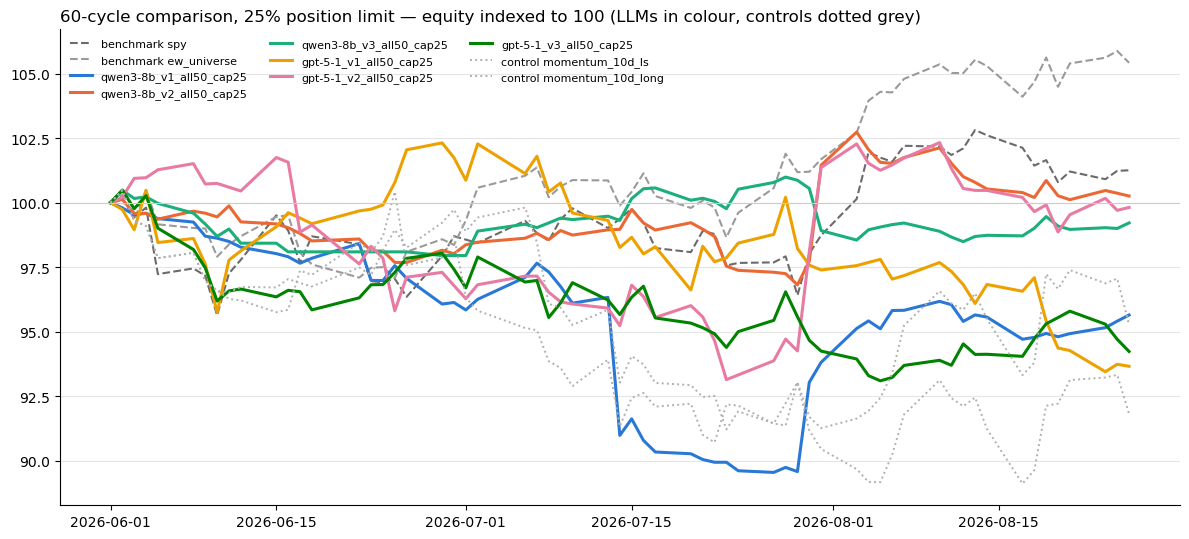

In [6]:
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#7a7a7a", "#8e6bbf"]
eq = pd.DataFrame({k: v["equity"] for k, v in results.items()}); eq_idx = eq / eq.iloc[0] * 100
bm = pd.DataFrame(benchmarks).reindex(eq.index).ffill(); bm = bm / bm.iloc[0] * 100
fig, ax = plt.subplots(figsize=(12, 5.5))
for col, c in zip(bm.columns, ["#6b6b6b", "#9a9a9a"]):
    ax.plot(bm.index, bm[col], "--", lw=1.5, color=c, label=f"benchmark {col}")
llm_cols = [c for c in eq_idx.columns if not c.startswith("control_")]; ctl_cols = [c for c in eq_idx.columns if c.startswith("control_")]
for i, col in enumerate(llm_cols):
    ax.plot(eq_idx.index, eq_idx[col], lw=2.2, color=PALETTE[i % len(PALETTE)], label=col)
for col in ctl_cols:
    ax.plot(eq_idx.index, eq_idx[col], ":", lw=1.4, color="#b0b0b0", label=col.replace("control_", "control "))
ax.axhline(100, color="#ccc", lw=0.8)
ax.set_title(f"{len(dds)}-cycle comparison, 25% position limit — equity indexed to 100 (LLMs in colour, controls dotted grey)", loc="left")
ax.legend(frameon=False, fontsize=8, ncol=3); ax.grid(axis="y", color="#e5e5e5"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Where the P&L comes from — concentration, stops, rule violations, and what each model actually did

`max_position_weight` is the largest single position as a share of equity, measured right after each fill (approximate: fill price against that day's closing equity); `best_trade_share_of_pnl` is the biggest trade's P&L over the total. A configuration whose return is one pyramided name shows a weight near 1 and a share above 1.

`best_trade_share_of_pnl` is blank when total P&L is zero or negative: the ratio has no meaning when the denominator is a loss, so it is left empty rather than printed as a misleading number. A blank there means the configuration lost money overall.

In [7]:
rows = []
for name in agents:
    res = results[name]; tr = res["trades"]
    rej = res["rejections"]["reason"].value_counts().to_dict() if not res["rejections"].empty else {}
    actions = pd.Series([d["action"] for r in res["log"] for d in r["decision"]["decisions"]]).value_counts().to_dict()
    holds = sum(1 for r in res["log"] if not r["decision"]["decisions"])
    cc = concentration(res["fills"], tr, res["equity"])
    rows.append({"config": name, "cycles_no_action": holds, "avg_holding_days": np.nan if tr.empty else float(tr["holding_days"].mean()),
                 "max_position_weight": cc["max_position_weight"], "max_gross_exposure": cc["max_gross_exposure"], "n_adds": cc["n_adds"],
                 "best_trade_pnl": cc["best_trade_pnl"], "best_trade_share_of_pnl": cc["best_trade_share"],
                 "total_fees": np.nan if tr.empty else float(tr["fees"].sum()), **{f"act_{k}": v for k, v in actions.items()},
                 "stopped_out": int((tr["reason"] == "invalidation").sum()) if not tr.empty else 0,
                 "closed_by_choice": int((tr["reason"] == "close").sum()) if not tr.empty else 0,
                 "closed_at_window_end": int((tr["reason"] == "end_of_window").sum()) if not tr.empty else 0,
                 "avg_stop_distance_pct": np.nan if tr.empty else float((abs(tr["entry_price"] - tr["exit_price"]) / tr["entry_price"])[tr["reason"] == "invalidation"].mean() * 100),
                 **{f"rej_{k[:28]}": v for k, v in rej.items()}})
pd.DataFrame(rows).set_index("config").T

config,qwen3-8b_v1_all50_cap25,qwen3-8b_v2_all50_cap25,qwen3-8b_v3_all50_cap25,gpt-5-1_v1_all50_cap25,gpt-5-1_v2_all50_cap25,gpt-5-1_v3_all50_cap25
cycles_no_action,7.000000,13.000000,55.000000,43.000000,38.000000,28.000000
avg_holding_days,4.642857,19.500000,12.800000,23.333333,27.500000,17.608696
max_position_weight,0.251237,0.251740,0.200966,0.254574,0.250952,0.200887
max_gross_exposure,0.251237,0.251740,0.200966,1.185062,0.899050,0.879536
n_adds,4.000000,2.000000,0.000000,1.000000,4.000000,0.000000
best_trade_pnl,603.358102,257.510102,126.502404,146.108477,406.030066,195.156613
best_trade_share_of_pnl,NaN,9.966461,NaN,NaN,NaN,NaN
total_fees,56.401530,17.733317,19.707974,57.145956,43.781224,69.351395
act_add,37.000000,42.000000,NaN,2.000000,7.000000,NaN
act_open_long,19.000000,8.000000,4.000000,15.000000,12.000000,23.000000


### Scaled fills

The engine never leverages: when a model asks for more than the free cash allows, the fill is scaled down to what fits and the shortfall is logged. A high count here means the model's sizing ignores its own portfolio state.

In [8]:
rows = []
for name in agents:
    sc = results[name]["scaled"]
    rows.append({"config": name, "n_scaled_fills": len(sc), "n_fills": len(results[name]["fills"]),
                 "avg_shortfall_pct": np.nan if sc.empty else float(sc["shortfall_pct"].mean()),
                 "worst_shortfall_pct": np.nan if sc.empty else float(sc["shortfall_pct"].max())})
scaled = pd.DataFrame(rows).set_index("config")
display(scaled.style.format({"avg_shortfall_pct": "{:.0f}%", "worst_shortfall_pct": "{:.0f}%"}, na_rep="—"))
for name in agents:
    if not results[name]["scaled"].empty:
        print(f"\n{name} — first scaled fills"); display(results[name]["scaled"].head(5))

,n_scaled_fills,n_fills,avg_shortfall_pct,worst_shortfall_pct
config,,,,
qwen3-8b_v1_all50_cap25,4,32,70%,77%
qwen3-8b_v2_all50_cap25,2,10,53%,53%
qwen3-8b_v3_all50_cap25,0,10,—,—
gpt-5-1_v1_all50_cap25,3,31,27%,56%
gpt-5-1_v2_all50_cap25,4,28,26%,57%
gpt-5-1_v3_all50_cap25,0,46,—,—



qwen3-8b_v1_all50_cap25 — first scaled fills


,date,symbol,action,requested_usd,filled_usd,shortfall_pct,reason
0,2026-06-15,CSCO,add,982.76,489.45,50.2,position_cap
1,2026-06-22,AMD,add,1956.95,449.43,77.0,position_cap
2,2026-07-06,IBM,add,1925.14,452.29,76.5,position_cap
3,2026-07-28,MSFT,add,1791.04,437.01,75.6,position_cap



qwen3-8b_v2_all50_cap25 — first scaled fills


,date,symbol,action,requested_usd,filled_usd,shortfall_pct,reason
0,2026-06-12,LLY,add,998.76,468.62,53.1,position_cap
1,2026-06-30,AMZN,add,981.58,468.35,52.3,position_cap



gpt-5-1_v1_all50_cap25 — first scaled fills


,date,symbol,action,requested_usd,filled_usd,shortfall_pct,reason
0,2026-06-05,GS,add,1004.81,440.84,56.1,position_cap
1,2026-07-13,META,open_long,996.00,752.02,24.5,cash_or_exposure
2,2026-07-16,BAC,open_long,1973.14,1967.00,0.3,cash_or_exposure



gpt-5-1_v2_all50_cap25 — first scaled fills


,date,symbol,action,requested_usd,filled_usd,shortfall_pct,reason
0,2026-06-05,WMT,add,1514.50,645.03,57.4,position_cap
1,2026-06-29,AMZN,add,971.14,960.24,1.1,position_cap
2,2026-07-21,MSFT,add,1152.15,824.07,28.5,position_cap
3,2026-08-07,LIN,add,1217.58,1001.28,17.8,position_cap


### Calibration — stated confidence against realised wins

Every open carries a confidence and the engine refuses to open below 0.80. This asks whether the number means anything: a reliability table per configuration and a Brier score (lower is better; a constant 0.5 forecast scores 0.25). Read it against two things — the trade count, since a Brier over four or five trades is a description rather than an estimate, and the spread of the buckets, since confidence that never varies cannot be calibrated, only compared with the realised rate.

In [9]:
# calibration: stated confidence vs realised win, per configuration (needs trades to be meaningful)
for name in agents:
    table, brier = calibration(results[name]["trades"])
    print(f"\n{name}: Brier {brier:.3f}" if brier == brier else f"\n{name}: no trades with confidence"); display(table)


qwen3-8b_v1_all50_cap25: Brier 0.669


,n,stated,realised
bucket,,,
"(0.799, 0.85]",14,0.847857,0.071429



qwen3-8b_v2_all50_cap25: Brier 0.547


,n,stated,realised
bucket,,,
"(0.799, 0.85]",4,0.85,0.25



qwen3-8b_v3_all50_cap25: Brier 0.582


...

,n,stated,realised
bucket,,,
"(0.799, 0.85]",15,0.822667,0.266667



gpt-5-1_v2_all50_cap25: Brier 0.467


,n,stated,realised
bucket,,,
"(0.799, 0.85]",12,0.825833,0.333333



gpt-5-1_v3_all50_cap25: Brier 0.575


,n,stated,realised
bucket,,,
"(0.799, 0.85]",23,0.831739,0.173913


## 6. Skill or luck? 1,000 random traders

Every random trader plays by the same rules on the same cycles, with no information at all: a coin decides whether to trade, which candidate name (the screened five or all 50, per the candidate mode), which side (500 seeds long/short, 500 long-only), and a size of 10/20/30% of equity. The result is the distribution of outcomes that luck alone produces on this window. A configuration at the 90th percentile beat nine random traders out of ten; anything between roughly the 20th and 80th is indistinguishable from a coin flip. Momentum controls and the two benchmarks get the same treatment.

About a minute on a laptop; cached to parquet afterwards.

In [10]:
from alphabench.null import run_null, null_table, null_summary

N_SEEDS = 500                                   # per side → 1,000 random traders
report = lambda done, n, s: print(f"\r  {done}/{n} seeds  {s:.0f}s", end="")
null = pd.concat([run_null(md, START, END, n_seeds=N_SEEDS, long_only=lo, cache_dir=ROOT / "data" / "results" / "compare" / "null", on_batch=report, payload_kwargs=PAYLOAD, max_position_weight=MAX_POSITION_WEIGHT)
                  for lo in (False, True)], ignore_index=True)
print(); display(null_summary(null).T.style.format("{:.3f}"))

side,"long/short, whole universe","long-only, whole universe"
n_seeds,500.000,500.000
share_positive_return,0.360,0.620
total_return_p05,-0.089,-0.064
total_return_median,-0.017,0.015
total_return_p95,0.070,0.105
sharpe_p05,-3.992,-2.410
sharpe_median,-0.603,0.562
sharpe_p95,2.591,3.418
max_drawdown_p05,-0.111,-0.090
max_drawdown_median,-0.056,-0.046


### A null that is allowed to pyramid

The random traders above never add to a position. These seeds may add to any position in profit (coin flip, 10-30% of equity each time), in this run's candidate mode. With the position limit in force the adds can no longer pile one name up to most of the account — compare the `max_position_weight` rows with notebook 03, where the pyramiding seeds' median was about 0.9. Compare `max_position_weight` here with the configurations' in section 5, and read the `_pyr` percentile columns for the prompts that pyramided. Slower: a few minutes.

In [11]:
null_pyr = pd.concat([run_null(md, START, END, n_seeds=N_SEEDS, long_only=lo, pyramid=True, cache_dir=ROOT / "data" / "results" / "compare" / "null", on_batch=report, payload_kwargs=PAYLOAD, max_position_weight=MAX_POSITION_WEIGHT)
                      for lo in (False, True)], ignore_index=True)
print(); display(null_summary(null_pyr).T.style.format("{:.3f}"))

side,"long/short, whole universe, pyramiding","long-only, whole universe, pyramiding"
n_seeds,500.000,500.000
share_positive_return,0.348,0.582
total_return_p05,-0.114,-0.073
total_return_median,-0.022,0.013
total_return_p95,0.090,0.122
sharpe_p05,-4.223,-2.474
sharpe_median,-0.679,0.475
sharpe_p95,2.420,3.130
max_drawdown_p05,-0.133,-0.108
max_drawdown_median,-0.068,-0.052


### The other candidate mode

The same 1,000 random traders again, in the other candidate mode (`OTHER`): if the notebook runs on the whole universe, this is the top-5 screener funnel, and vice versa. The difference between the two distributions is what the candidate list alone contributes — under the same rules, fees and stops. Run before the percentile table so it can show both.

side,long/short,long-only,"long/short, whole universe","long-only, whole universe"
n_seeds,500.000,500.000,500.000,500.000
share_positive_return,0.302,0.186,0.360,0.620
total_return_p05,-0.122,-0.127,-0.089,-0.064
total_return_median,-0.034,-0.048,-0.017,0.015
total_return_p95,0.063,0.036,0.070,0.105
sharpe_p05,-4.040,-4.111,-3.992,-2.410
sharpe_median,-0.983,-1.325,-0.603,0.562
sharpe_p95,1.846,1.052,2.591,3.418
max_drawdown_p05,-0.142,-0.139,-0.111,-0.090
max_drawdown_median,-0.077,-0.079,-0.056,-0.046


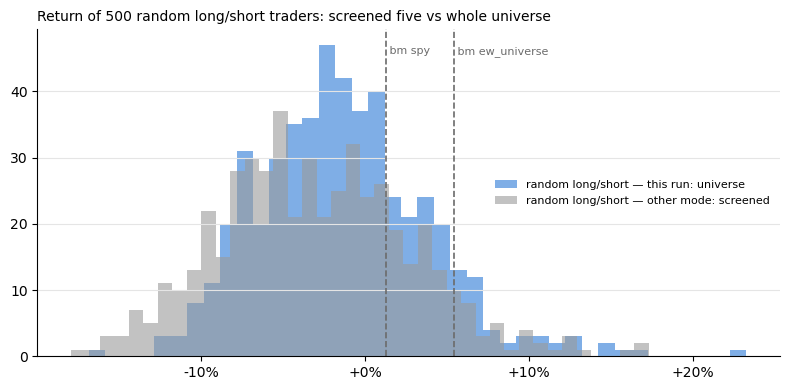

In [12]:
null_other = pd.concat([run_null(md, START, END, n_seeds=N_SEEDS, long_only=lo, cache_dir=ROOT / "data" / "results" / "compare" / "null", on_batch=report, payload_kwargs={"candidates": OTHER}, max_position_weight=MAX_POSITION_WEIGHT)
                        for lo in (False, True)], ignore_index=True)
print(); display(null_summary(pd.concat([null, null_other], ignore_index=True)).T.style.format("{:.3f}"))
fig, ax = plt.subplots(figsize=(8, 4))
for df_, c, lab in [(null, "#2a78d6", f"this run: {CANDIDATES}"), (null_other, "#9a9a9a", f"other mode: {OTHER}")]:
    ax.hist(df_.loc[~df_["long_only"], "total_return"], bins=40, color=c, alpha=0.6, label=f"random long/short — {lab}")
for k, v in benchmarks.items():
    ax.axvline(v.iloc[-1] / v.iloc[0] - 1, color="#6b6b6b", ls="--", lw=1.2); ax.text(v.iloc[-1] / v.iloc[0] - 1, ax.get_ylim()[1] * 0.95, " bm " + k, fontsize=8, color="#6b6b6b", va="top")
ax.set_title("Return of 500 random long/short traders: screened five vs whole universe", loc="left", fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}")); ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e5e5e5"); plt.tight_layout(); plt.show()

In [13]:
observed = lb.set_index("agent")[["total_return", "sharpe"]].copy()
for k, v in benchmarks.items():
    r = v.pct_change().dropna()
    observed.loc[f"benchmark_{k}"] = [v.iloc[-1] / v.iloc[0] - 1, float(r.mean() / r.std() * np.sqrt(252)) if r.std() > 0 else 0.0]
nt = null_table(observed, pd.concat([null, null_other, null_pyr], ignore_index=True)).sort_values("total_return", ascending=False)
nt.to_csv(RESULTS / "null_percentiles.csv")
nt.style.format({"total_return": "{:+.1%}", "sharpe": "{:.2f}", **{c: "{:.0f}" for c in nt.columns if "_pct_" in c}}).set_caption(
    f"Percentile within the random-trader distributions — ls = long/short, long = long-only; no suffix = picking from the screened five, _univ = all 50 names, _pyr = allowed to add to winners (this run: {CANDIDATES})")

,total_return,sharpe,total_return_pct_ls,total_return_pct_long,total_return_pct_ls_univ,total_return_pct_long_univ,total_return_pct_ls_univ_pyr,total_return_pct_long_univ_pyr,sharpe_pct_ls,sharpe_pct_long,sharpe_pct_ls_univ,sharpe_pct_long_univ,sharpe_pct_ls_univ_pyr,sharpe_pct_long_univ_pyr
agent,,,,,,,,,,,,,,
benchmark_ew_universe,+5.4%,1.98,93,98,91,75,90,75,96,99,91,80,92,80
benchmark_spy,+1.3%,0.44,78,88,73,48,75,50,77,88,72,47,74,50
qwen3-8b_v2_all50_cap25,+0.3%,0.16,72,83,65,40,68,43,72,83,65,41,68,44
gpt-5-1_v2_all50_cap25,-0.2%,0.03,69,80,63,37,64,41,70,80,64,38,65,41
qwen3-8b_v3_all50_cap25,-0.8%,-0.53,66,78,57,33,61,37,59,70,52,27,54,28
qwen3-8b_v1_all50_cap25,-4.4%,-1.09,44,54,29,12,34,16,47,57,40,20,41,20
control_momentum_10d_long,-4.7%,-1.10,43,51,26,11,31,15,47,57,40,20,41,19
gpt-5-1_v3_all50_cap25,-5.8%,-2.35,34,40,20,8,24,9,23,25,20,6,19,6
gpt-5-1_v1_all50_cap25,-6.3%,-1.79,31,36,18,5,21,6,34,39,27,11,28,9


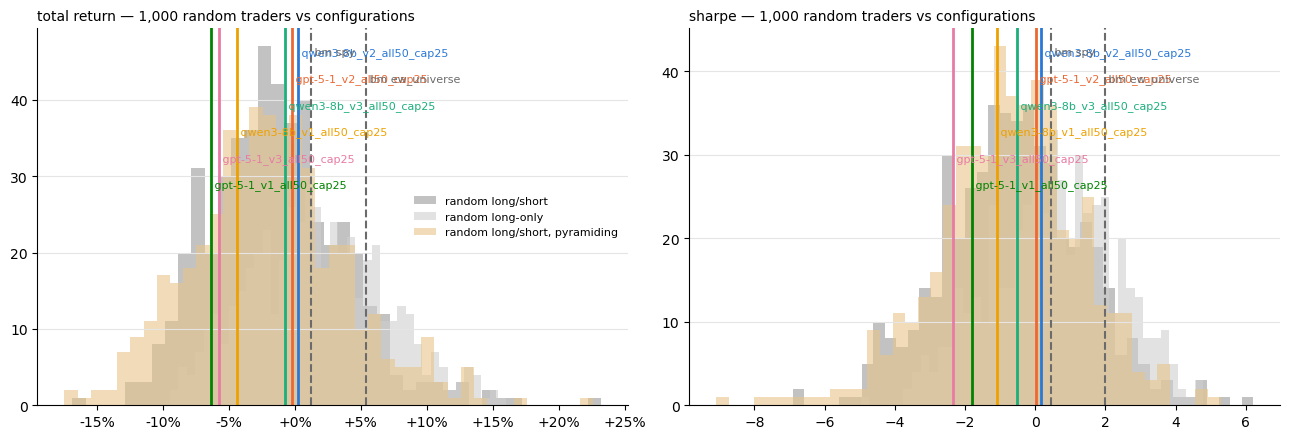

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, m, fmt in zip(axes, ["total_return", "sharpe"], ["{:+.0%}", "{:.1f}"]):
    for df_, lo, c, lab in [(null, False, "#9a9a9a", "random long/short"), (null, True, "#cfcfcf", "random long-only"), (null_pyr, False, "#e8c48a", "random long/short, pyramiding")]:
        ax.hist(df_.loc[df_["long_only"] == lo, m], bins=40, color=c, alpha=0.6, label=lab)
    ymax = ax.get_ylim()[1]
    for i, name in enumerate([n for n in observed.index if not n.startswith("control_")]):
        x = observed.loc[name, m]
        col = "#6b6b6b" if name.startswith("benchmark_") else PALETTE[i % len(PALETTE)]
        ax.axvline(x, color=col, lw=2 if not name.startswith("benchmark_") else 1.5, ls="-" if not name.startswith("benchmark_") else "--")
        ax.text(x, ymax * (0.95 - 0.07 * (i % 6)), " " + name.replace("benchmark_", "bm "), color=col, fontsize=8, va="top")
    ax.set_title(f"{m.replace('_', ' ')} — 1,000 random traders vs configurations", loc="left", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e5e5e5")
    if m == "total_return": ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
axes[0].legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

## 7. What this run found

*Two runs on the same 60 cycles, 1 June to 25 August 2026, whole-universe candidates, 25% position limit: qwen3:8b on a laptop (9 September 2026) and gpt-5.1 through the OpenAI API at `reasoning_effort="low"` (14 September 2026, 182 live calls, $3.39). The tables above are the evidence; this section states the reading so that nobody has to derive it.*

**Nothing beat holding the universe, at either model size.** The equal-weight index of the same 50 names returned +5.4% at a Sharpe of 1.98 — better than 91% of the random long/short traders. The best configuration in the table is qwen3:8b with prompt v2 at +0.3%; the best gpt-5.1 configuration is v2 at -0.2%. The other four prompt runs finished between -0.8% and -6.3%. Both benchmarks beat all six; the momentum controls (-4.7% long-only, -8.2% long/short) sit among them.

**The frontier model did not move the return, and its percentiles are lower.** gpt-5.1 finished at -6.3% (v1), -0.2% (v2) and -5.8% (v3), against qwen3:8b's -4.4%, +0.3% and -0.8%. Against 1,000 random long/short traders drawn from the same universe under the same rules: gpt-5.1 at the 18th, 63rd and 20th percentiles; qwen3:8b at the 29th, 65th and 57th. gpt-5.1 never opened a short in 50 trades, so the long-only null is the fair comparison for it, and there it sits at the 5th, 37th and 8th percentiles. Two of its three prompts are at the bottom edge of the band this notebook calls luck. Sixty cycles and 12 to 23 trades cannot tell "unlucky" from "worse", but they can rule out "better": on prices alone, the larger model shows no edge the smaller one lacked.

**What the frontier model did change is behaviour, and every change is visible in section 5.** No invalid output in 182 calls and two repairs in total, against 25 for qwen3:8b. Rule violations of 5%, 14% and 0% against 68%, 86% and 0% — gpt-5.1 does not ask for adds to losing positions or for second opens in a cycle. Every open sized at or under the cap; only adds were scaled back by it (one for v1, four for v2). Stops placed at 5.4% to 7.6% from entry instead of 2.4% to 3.8%, so it was stopped out five times per run instead of up to twelve, and it closed positions by choice (5, 3 and 14 times) far more than qwen3:8b (1, 1 and 0). It did more with the full decision procedure, not less: v3 traded 23 times and acted in 32 of 60 cycles, where qwen3:8b's v3 traded 5 times and acted in 5. And it held longer: 17 to 28 days on average against 5 to 20. This is a model that follows the mandate. It is not a model that finds anything in the price data, and a mandate followed precisely on a signal that is not there produces a tidy sequence of small losses: 19 of gpt-5.1 v3's 23 trades lost, twelve of them closed by choice at -1% to -5% before the stop was hit, and its two largest winners were still open when the window closed.

**Stated confidence still carries no information, and now the gate is visible.** Every one of qwen3:8b's 23 trades stated 0.85; every one of gpt-5.1's 50 stated 0.81 to 0.84. Realised win rates were 7% to 25% for qwen3:8b and 17% to 33% for gpt-5.1. The Brier scores (0.669, 0.547, 0.582 against 0.506, 0.467, 0.575) improve only because gpt-5.1's number is a little lower, not because it tracks anything. Both models write the smallest number that clears the 0.80 the engine requires to open — a floor that the prompt states and that both treat as the price of admission. The finding is not "the models are overconfident"; it is that the confidence field, as this harness asks for it, is answered as a permission rather than a probability. Every trade of both models sits in the single bucket above the gate, so the reliability tables are one row each and no calibration curve exists to draw. Asking for a probability without a threshold, or scoring a forecast that is separate from the decision to act, is the next design change, before any bigger model is tried.

**Adding risk rules to the prompt made rule-following worse for the small model and not for the large one.** v2 is v1 plus risk rules. For qwen3:8b the engine had to refuse 86% of v2's decision items against v1's 68%, mostly adds to positions not in profit or already at the cap; the rules changed what it asked for without changing what it understood about its own book. For gpt-5.1 the refusal rate is 14% against 5%, all of it adds — to a name at the cap or not yet in profit. v3, the full decision procedure, produced zero violations from both models, which remains the one clear win for prompt engineering in this table.

**What the position limit changed.** Notebook 03, without the limit, put qwen3:8b v1 at +11.0% and the 98th percentile of the plain null — a return produced by adding to one name until it was most of the account, and one that sits at the 90th percentile of the *pyramiding* null, which is the comparison it actually deserves. With the cap in force v1 is the worst of the three for both models. The cap did not make the prompts better; it removed one prompt's licence to place a bet large enough to dominate the comparison. That is the whole reason both notebooks exist.

**Cost.** The three gpt-5.1 runs took 45 minutes of wall clock and $3.39 at 12 to 19 seconds a call; the cache makes every re-run free. A frontier model is not the expensive part of this experiment.

### What would change the conclusion

- **A confidence that is not a gate.** Both models answered the confidence field with the smallest value that lets a trade through. `notebooks/05_forecast_first.ipynb` asks for a forecast first and decides afterwards; until confidence is scored on its own, nothing here says whether either model can rank its own ideas.
- **Information, not model size.** Going from 8B parameters on a laptop to a frontier model changed behaviour and not return, on prices alone. The next input to add is what the price data does not contain — company filings — and the metric to watch first is whether confidence starts to vary.
- **Reasoning budget.** gpt-5.1 ran at `reasoning_effort="low"`; `medium` or `high` costs two to three times more and is untested here.
- **More trades, not more cycles.** Sixty cycles is enough to measure rule-following and validity. It is not enough to separate returns when the configurations trade four to twenty-three times. Trade count is the binding constraint on everything in section 4.
- **Other windows.** Everything above is one rising quarter. A finding that survives 2024 and 2025 is a finding; this one is a reading.
- **A better null, not a better story.** The honest summary of any configuration is its percentile, not its return. Anything inside the middle of the random-trader distribution has shown nothing, however green the equity curve looks.